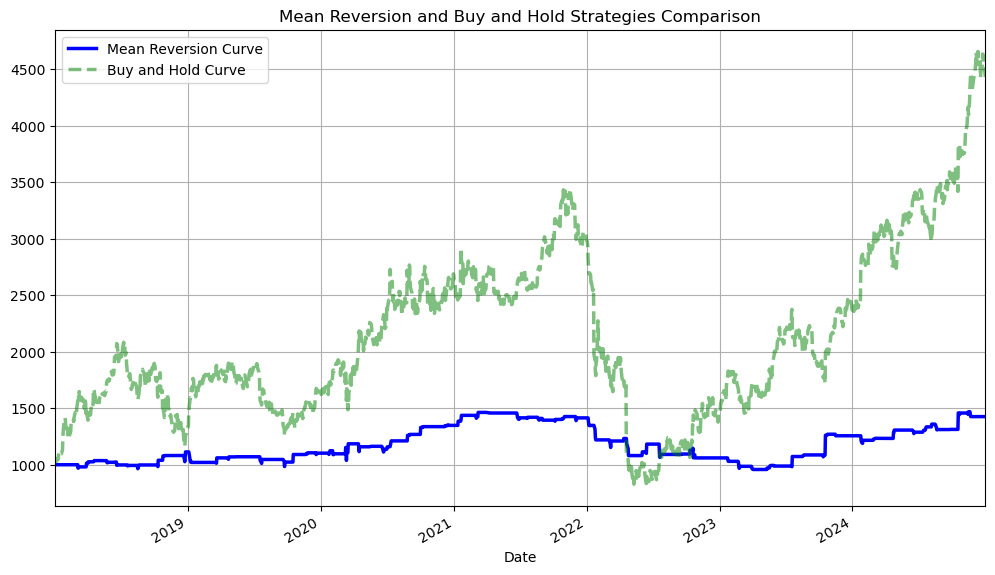

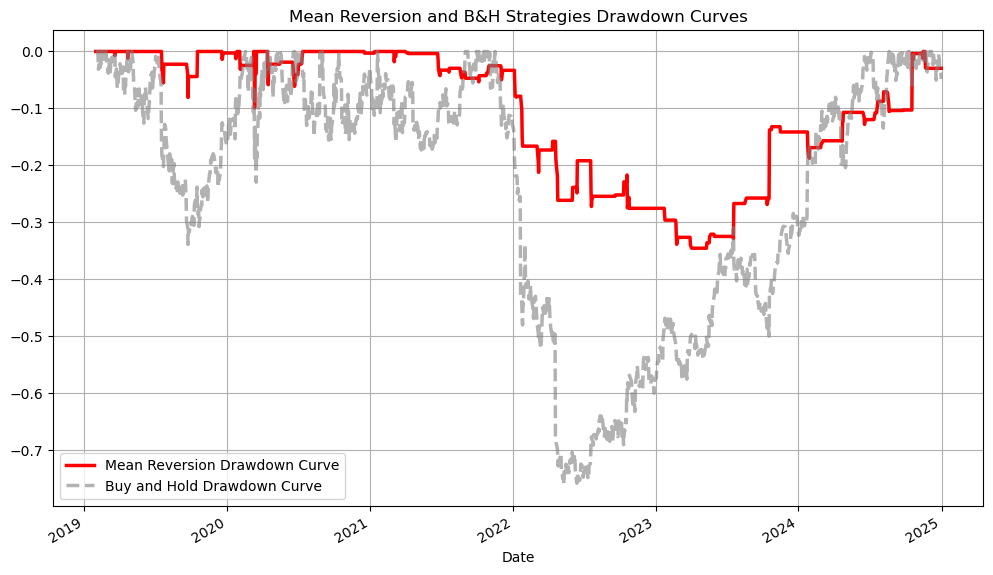

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from Fonctions import compute_metrics, drawdown

data = pd.read_csv("NFLX_data.csv", parse_dates = True, header=[0,1], index_col = 0)
price = data["Close"]["NFLX"]
data_return = pd.read_csv("NFLX_data_return.csv", parse_dates = True, index_col = 0).squeeze()


sma = price.rolling(20).mean()
sma_vol = price.rolling(20).std()

plus_band = sma + 2*sma_vol
minus_band = sma - 2*sma_vol
z_score = (price-sma)/sma_vol
signal = pd.Series(0, index=z_score.index)
signal[z_score > 2] = -1
signal[z_score < -2] = 1
strat_return = signal.shift(1)*data_return

V0=1000
equity_curve = V0*np.exp(strat_return.cumsum())
equity_bandh = V0 * np.exp(data_return.cumsum())
equity_curve_filtered = equity_curve["2019-01-31":]
equity_bandh_filtered = equity_bandh["2019-01-31":]

plt.figure(figsize=(12,7))
equity_curve.plot(color="blue",linewidth = 2.5, label = "Mean Reversion Curve")
equity_bandh.plot(color="green", linewidth = 2.5, label = "Buy and Hold Curve",linestyle = '--', alpha = 0.5)
plt.title("Mean Reversion and Buy and Hold Strategies Comparison")
plt.grid()
plt.legend()
plt.xlim(equity_curve.index[0], equity_curve.index[-1])
plt.show()
data_return_filtered = data_return["2019-01-31":]
strat_filtered = strat_return["2019-01-31":]

plt.figure(figsize = (12,7))
drawdown(equity_curve_filtered).plot(color = "red", linewidth = 2.5, label = "Mean Reversion Drawdown Curve")
drawdown(equity_bandh_filtered).plot(color = "grey", linewidth = 2.5, linestyle = "--", label = "Buy and Hold Drawdown Curve", alpha = 0.6)
plt.title ("Mean Reversion and B&H Strategies Drawdown Curves")
plt.grid()
plt.legend()
plt.show()

pd.DataFrame({
    "Mean Reversion": compute_metrics(strat_filtered, equity_curve_filtered, freq="daily"),
    "Buy and Hold": compute_metrics(data_return_filtered, equity_bandh_filtered, freq="daily")
})
compute_metrics(strat_filtered, equity_curve_filtered, freq="daily").to_csv("metrics_meanreversion.csv")